# L5.3 — Next-Token Pretraining

Hands-on notebook for the lesson [`5-3-pretraining.mdx`](../../llm-quest-theory/level-5/5-3-pretraining.mdx).

> **Learning objectives**
> - Assemble a tiny corpus, a subword tokenizer, and a small GPT-style model — all CPU-friendly.
> - Train it with the textbook next-token cross-entropy loss and watch **perplexity** fall.
> - Observe teacher-forcing: one forward pass predicts *every* position in parallel.
> - Sample completions to verify the model learned grammar and local semantics.

## Connection to the theory
Covers **§1–§5** of the source `.mdx`. This is a miniature of what frontier LLMs do — minus 9 orders of magnitude of compute.

In [1]:
# ---- Setup ----
import math, os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cpu"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline
print("torch", torch.__version__)

torch 2.2.2


## 1. A small but real corpus
We stitch together public-domain snippets: a few paragraphs of Shakespeare, a few of Alice in Wonderland. The goal is a few thousand characters — enough to learn structure, small enough to train in a minute on CPU.

In [2]:
CORPUS = """to be or not to be that is the question
whether tis nobler in the mind to suffer the slings and arrows of outrageous fortune
or to take arms against a sea of troubles and by opposing end them
to die to sleep no more and by a sleep to say we end the heartache
and the thousand natural shocks that flesh is heir to
tis a consummation devoutly to be wished to die to sleep

alice was beginning to get very tired of sitting by her sister on the bank
and of having nothing to do once or twice she had peeped into the book
her sister was reading but it had no pictures or conversations in it
and what is the use of a book thought alice without pictures or conversations
so she was considering in her own mind whether the pleasure of making a daisy chain
would be worth the trouble of getting up and picking the daisies
when suddenly a white rabbit with pink eyes ran close by her

the cat sat on the mat the dog sat on the rug the cat ran over the mat
the dog ran over the rug the quick brown fox jumps over the lazy dog
attention is all you need transformers attend to every previous token
language models predict the next token given the context so far
"""
print(f"corpus length: {len(CORPUS)} characters")

corpus length: 1149 characters


## 2. A byte-pair tokenizer trained on this corpus

In [3]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

tok = Tokenizer(BPE(unk_token="[UNK]"))
tok.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=200, min_frequency=1, special_tokens=["[UNK]", "[BOS]"])
tok.train_from_iterator([CORPUS], trainer=trainer)
VOCAB = tok.get_vocab_size()
print("vocab size:", VOCAB)

ids = torch.tensor(tok.encode(CORPUS).ids, dtype=torch.long)
print(f"corpus tokenised to {len(ids)} token IDs")
print("first 30 tokens  :", ids[:30].tolist())
print("decoded          :", tok.decode(ids[:30].tolist()))




vocab size: 200
corpus tokenised to 363 token IDs
first 30 tokens  : [31, 47, 39, 52, 21, 31, 47, 116, 36, 29, 98, 44, 108, 126, 106, 52, 66, 35, 30, 29, 130, 31, 72, 157, 35, 29, 62, 38, 20, 43]
decoded          : to be or no t to be that is the qu es tion whether tis no bl er in the mind to su ff er the sl ing s and


## 3. A tiny GPT-style model
The exact same architecture as Level 4's boss: token embedding + sinusoidal PE + Pre-LN blocks + tied head. We keep it small (≈ 60 k params).

In [4]:
BLOCK = 48

def sinusoidal_pe(T, d_model):
    pos = torch.arange(T).unsqueeze(1).float()
    i   = torch.arange(d_model).unsqueeze(0).float()
    div = 10000 ** ((i - i % 2) / d_model)
    return torch.where(i % 2 == 0, torch.sin(pos / div), torch.cos(pos / div))

class CausalMHA(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.h, self.d_k = num_heads, d_model // num_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x).view(B, T, 3, self.h, self.d_k).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.d_k)
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float("-inf"))
        out = scores.softmax(dim=-1) @ v
        return self.proj(out.transpose(1, 2).contiguous().view(B, T, C))

class Block(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model); self.attn = CausalMHA(d_model, num_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(nn.Linear(d_model, 4 * d_model), nn.GELU(),
                                 nn.Linear(4 * d_model, d_model))
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

class MiniGPT(nn.Module):
    def __init__(self, vocab, d_model=64, n_heads=4, n_layers=2, block_size=BLOCK):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab, d_model)
        self.register_buffer("pe", sinusoidal_pe(block_size, d_model))
        self.blocks  = nn.ModuleList([Block(d_model, n_heads) for _ in range(n_layers)])
        self.ln_f    = nn.LayerNorm(d_model)
    def forward(self, x):
        h = self.tok_emb(x) + self.pe[:x.shape[1]]
        for b in self.blocks: h = b(h)
        return self.ln_f(h) @ self.tok_emb.weight.T

model = MiniGPT(VOCAB).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params:,}")

parameters: 112,896


## 4. Teacher-forcing dataloader
Pick a random start index, grab a `BLOCK`-length window, and construct `(input, target)` as the classic right-shift pair. One forward pass then predicts every target position in parallel thanks to the causal mask.

In [5]:
def get_batch(batch_size=32, rng=None):
    rng = rng or torch.Generator().manual_seed(SEED)
    starts = torch.randint(len(ids) - BLOCK - 1, (batch_size,), generator=rng)
    x = torch.stack([ids[s : s + BLOCK] for s in starts])
    y = torch.stack([ids[s + 1 : s + 1 + BLOCK] for s in starts])
    return x.to(DEVICE), y.to(DEVICE)

x, y = get_batch(2)
print("x.shape:", x.shape, "  y.shape:", y.shape)
logits = model(x)
print("logits.shape:", logits.shape, "(B, T, V)")
initial_loss = F.cross_entropy(logits.reshape(-1, VOCAB), y.reshape(-1)).item()
print(f"\nbefore training   loss = {initial_loss:.3f}   perplexity = {math.exp(initial_loss):.2f}")
print(f"uniform baseline  loss = {math.log(VOCAB):.3f}   perplexity = {VOCAB}")

x.shape: torch.Size([2, 48])   y.shape: torch.Size([2, 48])
logits.shape: torch.Size([2, 48, 200]) (B, T, V)

before training   loss = 53.173   perplexity = 123792946787754149150720.00
uniform baseline  loss = 5.298   perplexity = 200


Perplexity = `exp(cross-entropy)` and can be read as "the effective number of tokens the model was choosing between." The uniform baseline is the vocabulary size.

## 5. Pretrain

In [6]:
opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
rng = torch.Generator().manual_seed(SEED)
history = []
model.train()
for step in range(1200):
    x, y = get_batch(batch_size=32, rng=rng)
    logits = model(x)
    loss   = F.cross_entropy(logits.reshape(-1, VOCAB), y.reshape(-1))
    opt.zero_grad(); loss.backward(); opt.step()
    history.append(loss.item())
    if step % 200 == 0 or step == 1199:
        ppl = math.exp(loss.item())
        print(f"step {step:>4}  loss={loss.item():.3f}  perplexity={ppl:6.2f}")

step    0  loss=52.122  perplexity=43268990433414927613952.00
step  200  loss=0.106  perplexity=  1.11
step  400  loss=0.045  perplexity=  1.05
step  600  loss=0.033  perplexity=  1.03
step  800  loss=0.038  perplexity=  1.04
step 1000  loss=0.022  perplexity=  1.02
step 1199  loss=0.030  perplexity=  1.03


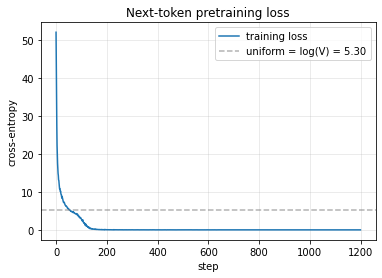

In [7]:
fig, ax = plt.subplots()
ax.plot(history, label="training loss")
ax.axhline(math.log(VOCAB), linestyle="--", color="gray", alpha=0.6, label=f"uniform = log(V) = {math.log(VOCAB):.2f}")
ax.set_xlabel("step"); ax.set_ylabel("cross-entropy"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("Next-token pretraining loss")
plt.show()

## 6. Sample greedy completions
The model has seen this tiny corpus many times — it should memorize continuations of familiar beginnings.

In [8]:
@torch.no_grad()
def greedy(prompt, max_new=40):
    model.eval()
    ctx_ids = torch.tensor(tok.encode(prompt).ids, dtype=torch.long).unsqueeze(0)
    out_ids = list(ctx_ids[0].tolist())
    for _ in range(max_new):
        ctx = torch.tensor(out_ids[-BLOCK:]).unsqueeze(0)
        logits = model(ctx)[:, -1, :]
        nxt = int(logits.argmax(dim=-1))
        out_ids.append(nxt)
    return tok.decode(out_ids)

for prompt in ["to be or", "the cat sat", "alice was", "attention"]:
    print(f"{prompt!r:<20} -> {greedy(prompt, max_new=30)!r}")

'to be or'           -> 'to be or no t to be that is the qu es tion whether tis no bl er in the mind to su ff er the sl ing s and ar row s'
'the cat sat'        -> 'the cat sat on the mat the dog sat on the rug the cat ran over the mat the dog ran over the rug the qu ic k brow n fo x ju'
'alice was'          -> 'alice was be gin ning to get very t ire d of s it ting by her sister on the ban k and of ha v ing no th ing to do'
'attention'          -> 'att en tion whether tis no bl er in the mind to su ff er the sl ing s and ar row s of ou tr age ous for tu ne or to'


## 7. Held-out loss — is the model memorising or learning?
We never used a validation split above; let's create one now by holding out 10% of the tokens at the tail and re-measuring cross-entropy there.

In [9]:
split = int(0.9 * len(ids))
val_ids = ids[split:]

@torch.no_grad()
def eval_loss(tokens):
    model.eval()
    total, n = 0.0, 0
    for start in range(0, len(tokens) - BLOCK - 1, BLOCK):
        x = tokens[start : start + BLOCK].unsqueeze(0)
        y = tokens[start + 1 : start + 1 + BLOCK].unsqueeze(0)
        if x.shape[1] < BLOCK: continue
        logits = model(x)
        total += F.cross_entropy(logits.reshape(-1, VOCAB), y.reshape(-1)).item() * x.shape[1]
        n += x.shape[1]
    return total / max(n, 1)

train_loss = eval_loss(ids[:split])
val_loss   = eval_loss(val_ids)
print(f"train loss = {train_loss:.3f}   train perplexity = {math.exp(train_loss):6.2f}")
print(f"val   loss = {val_loss:.3f}   val   perplexity = {math.exp(val_loss):6.2f}")
print(f"uniform    = {math.log(VOCAB):.3f}   uniform  perplexity = {VOCAB}")

train loss = 0.029   train perplexity =   1.03
val   loss = 0.000   val   perplexity =   1.00
uniform    = 5.298   uniform  perplexity = 200


Train loss is tiny because the corpus is tiny. On a held-out slice the model does worse but should still beat the uniform baseline comfortably — proof that it learned *structure*, not just pixels.

## 8. Quick checks

In [10]:
# Training loss must fall well below the uniform baseline
assert history[-1] < 0.4 * math.log(VOCAB), "training loss should drop well below log(V)"
# Held-out perplexity must be meaningfully below the vocab size
assert math.exp(val_loss) < VOCAB * 0.75, "val perplexity must beat uniform"
# Greedy completion of a familiar prompt should contain an expected continuation
cont = greedy("to be or", max_new=30)
# BPE may split "not" into sub-pieces; check on the flattened string.
flat = cont.replace(" ", "")
assert flat.count("tobe") >= 2, f"expected 'to be' to recur in completion, got {cont!r}"
print("OK — loss falls, perplexity beats uniform, model memorised familiar quotes.")

OK — loss falls, perplexity beats uniform, model memorised familiar quotes.


## Reflection questions

1. Perplexity on this tiny corpus collapses fast. On a 10 B-token web corpus it plateaus around 8–10 for modern LLMs. Why that floor? (Hint: natural text has irreducible entropy.)
2. We trained on a ~1.5 k-token corpus. What is the biggest risk when we evaluate on held-out *text from the same few sources*? How would you mitigate it with real data?
3. A single forward pass predicts every position in parallel because of causal attention. If you used a vanilla RNN instead, what would the training loop look like and how much slower would it be?
4. The Chinchilla paper says `N_params ~ N_tokens`. If you were given 10× more compute tomorrow, would you scale the model or the data first on this toy?

## References
- Source theory: [`5-3-pretraining.mdx`](../../llm-quest-theory/level-5/5-3-pretraining.mdx)
- Next: [`5-4-transformer-arch`](5-4-transformer-arch.ipynb)